# 03 Visualization and Business Insights

In this notebook, I convert the cleaned Tata Motors financial datasets into business-friendly insights and visuals.

My goal here is to move beyond basic calculations and answer the main business questions behind the numbers:

- How did revenue and profitability move from FY2021 to FY2025?
- Did Tata Motors improve its margins and returns?
- Is the liquidity position healthy?
- Did debt pressure reduce over time?
- Is cash flow supporting business growth?
- What strengths, risks, and recommendations can I present in the final project?

The output of this notebook will support the final dashboard, README, report, and resume explanation.

## 1. Import libraries

In this step, I import the libraries required for loading data, creating insight tables, and saving charts.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

## 2. Set project paths

In this step, I locate the project root and define the folders that I will use for cleaned data, reports, and charts.

In [2]:
def find_project_root(start_path: Path) -> Path:
    """I search upward until I find the project folder containing data/cleaned."""
    current = start_path.resolve()
    for path in [current] + list(current.parents):
        if (path / "data" / "cleaned").exists():
            return path
    raise FileNotFoundError("I could not find the project root. Please run this notebook from inside the project folder.")

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data" / "cleaned"
REPORTS_DIR = PROJECT_ROOT / "reports"
CHARTS_DIR = REPORTS_DIR / "charts"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Cleaned data folder:", DATA_DIR)
print("Reports folder:", REPORTS_DIR)
print("Charts folder:", CHARTS_DIR)

Project root: D:\Github Project\Tata Motors Financial Analysis
Cleaned data folder: D:\Github Project\Tata Motors Financial Analysis\data\cleaned
Reports folder: D:\Github Project\Tata Motors Financial Analysis\reports
Charts folder: D:\Github Project\Tata Motors Financial Analysis\reports\charts


## 3. Load the cleaned datasets

In this step, I load the validated financial dataset and the financial ratios file created in the previous notebooks.

In [3]:
def load_csv_if_exists(file_name: str) -> pd.DataFrame:
    """I load a CSV only if it exists, so the notebook gives a clear error when a required file is missing."""
    file_path = DATA_DIR / file_name
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")
    return pd.read_csv(file_path)

ratios = load_csv_if_exists("financial_ratios.csv")

validated_path = DATA_DIR / "validated_financial_dataset.csv"
if validated_path.exists():
    validated = pd.read_csv(validated_path)
else:
    # I use the ratios file as the main analysis base if the validation output has not been generated yet.
    validated = ratios.copy()

print("Ratios shape:", ratios.shape)
print("Validated dataset shape:", validated.shape)

display(ratios.head())

Ratios shape: (5, 35)
Validated dataset shape: (5, 160)


,financial_year,revenue_from_operations_cr,total_income_cr,profit_before_tax_cr,profit_after_tax_cr,total_assets_cr,total_equity_cr,total_liabilities_cr,current_assets_cr,current_liabilities_cr,cash_and_cash_equivalents_cr,current_investments_cr,total_borrowings_cr,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,capex_payments_cr,net_profit_margin_pct,pbt_margin_pct,expense_to_income_ratio_pct,return_on_assets_pct,return_on_equity_pct,asset_turnover_ratio,current_ratio,quick_ratio,cash_ratio,working_capital_cr,debt_to_equity_ratio,debt_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct,capex_to_revenue_pct,source_income_statement,source_balance_sheet,source_cash_flow,notes
0,FY2020-21,249794.75,252437.94,-10474.28,-13395.10,343125.80,56820.21,286305.59,146887.64,157749.18,31700.01,19051.19,114775.56,29000.51,5317.0,-20205.40,-5.36,-4.19,98.70,-3.90,-23.57,0.728,0.93,0.70,0.32,-10861.54,2.02,0.83,11.61,2.13,8.09,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
1,FY2021-22,278453.62,281507.25,-7003.41,-11308.76,330619.93,48832.30,281787.63,146977.54,150682.81,38159.01,22709.22,139677.04,14282.83,-9254.0,-15168.42,-4.06,-2.52,102.26,-3.36,-21.41,0.827,0.98,0.74,0.40,-3705.27,2.86,0.85,5.13,-3.32,5.45,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
2,FY2022-23,345966.97,350600.15,3057.55,2689.87,336081.38,52599.51,283481.87,151528.47,155027.33,31886.95,18838.31,125660.47,35388.01,7840.0,-18095.68,0.78,0.88,99.58,0.81,5.30,1.038,0.98,0.71,0.33,-3498.86,2.39,0.84,10.23,2.27,5.23,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
3,FY2023-24,437927.77,443877.69,27955.11,31806.75,370663.96,93093.93,277570.03,168392.15,173617.00,40014.76,14253.24,98500.09,67915.36,26924.0,-31413.63,7.26,6.38,93.64,9.00,43.66,1.239,0.97,0.69,0.31,-5224.85,1.06,0.75,15.51,6.15,7.17,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
4,FY2024-25,439695.00,445939.00,33780.00,28149.00,378642.00,122754.00,255888.00,160325.00,166684.00,34349.00,27199.00,62499.00,63102.00,22348.0,-38042.00,6.40,7.68,92.37,7.51,26.08,1.174,0.96,0.68,0.37,-6359.00,0.51,0.68,14.35,5.08,8.65,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...


## 4. Clean and standardize the analysis base

In this step, I standardize financial year labels and sort the data chronologically so that all charts and insights are consistent.

In [4]:
def standardize_financial_year(value):
    """I convert different year formats into one clean FY label."""
    value = str(value).strip()
    mapping = {
        "FY2020-21": "FY2021", "FY2020_21": "FY2021", "FY2021": "FY2021",
        "FY2021-22": "FY2022", "FY2021_22": "FY2022", "FY2022": "FY2022",
        "FY2022-23": "FY2023", "FY2022_23": "FY2023", "FY2023": "FY2023",
        "FY2023-24": "FY2024", "FY2023_24": "FY2024", "FY2024": "FY2024",
        "FY2024-25": "FY2025", "FY2024_25": "FY2025", "FY2025": "FY2025",
    }
    return mapping.get(value, value)

analysis = ratios.copy()
analysis["financial_year"] = analysis["financial_year"].apply(standardize_financial_year)
analysis = analysis.drop_duplicates(subset=["financial_year"], keep="last")
analysis = analysis.sort_values("financial_year").reset_index(drop=True)

expected_years = ["FY2021", "FY2022", "FY2023", "FY2024", "FY2025"]
actual_years = analysis["financial_year"].tolist()

print("Financial years available:", actual_years)

if actual_years != expected_years:
    raise ValueError(f"The financial years are not clean yet. Expected {expected_years}, but found {actual_years}")

display(analysis)

Financial years available: ['FY2021', 'FY2022', 'FY2023', 'FY2024', 'FY2025']


,financial_year,revenue_from_operations_cr,total_income_cr,profit_before_tax_cr,profit_after_tax_cr,total_assets_cr,total_equity_cr,total_liabilities_cr,current_assets_cr,current_liabilities_cr,cash_and_cash_equivalents_cr,current_investments_cr,total_borrowings_cr,net_cash_from_operating_activities_cr,auto_free_cash_flow_cr,capex_payments_cr,net_profit_margin_pct,pbt_margin_pct,expense_to_income_ratio_pct,return_on_assets_pct,return_on_equity_pct,asset_turnover_ratio,current_ratio,quick_ratio,cash_ratio,working_capital_cr,debt_to_equity_ratio,debt_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct,capex_to_revenue_pct,source_income_statement,source_balance_sheet,source_cash_flow,notes
0,FY2021,249794.75,252437.94,-10474.28,-13395.10,343125.80,56820.21,286305.59,146887.64,157749.18,31700.01,19051.19,114775.56,29000.51,5317.0,-20205.40,-5.36,-4.19,98.70,-3.90,-23.57,0.728,0.93,0.70,0.32,-10861.54,2.02,0.83,11.61,2.13,8.09,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
1,FY2022,278453.62,281507.25,-7003.41,-11308.76,330619.93,48832.30,281787.63,146977.54,150682.81,38159.01,22709.22,139677.04,14282.83,-9254.0,-15168.42,-4.06,-2.52,102.26,-3.36,-21.41,0.827,0.98,0.74,0.40,-3705.27,2.86,0.85,5.13,-3.32,5.45,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
2,FY2023,345966.97,350600.15,3057.55,2689.87,336081.38,52599.51,283481.87,151528.47,155027.33,31886.95,18838.31,125660.47,35388.01,7840.0,-18095.68,0.78,0.88,99.58,0.81,5.30,1.038,0.98,0.71,0.33,-3498.86,2.39,0.84,10.23,2.27,5.23,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
3,FY2024,437927.77,443877.69,27955.11,31806.75,370663.96,93093.93,277570.03,168392.15,173617.00,40014.76,14253.24,98500.09,67915.36,26924.0,-31413.63,7.26,6.38,93.64,9.00,43.66,1.239,0.97,0.69,0.31,-5224.85,1.06,0.75,15.51,6.15,7.17,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...
4,FY2025,439695.00,445939.00,33780.00,28149.00,378642.00,122754.00,255888.00,160325.00,166684.00,34349.00,27199.00,62499.00,63102.00,22348.0,-38042.00,6.40,7.68,92.37,7.51,26.08,1.174,0.96,0.68,0.37,-6359.00,0.51,0.68,14.35,5.08,8.65,income_statement_combined_FY2021_to_FY2025.csv,balance_sheet_combined_FY2021_to_FY2025.csv,cash_flow_statement_combined_FY2021_to_FY2025.csv,ROA/ROE/asset turnover use average assets/equi...


## 5. Create helper calculations

In this step, I calculate growth metrics that will help me explain the financial story clearly.

In [5]:
def safe_pct_change(series):
    """I calculate year-on-year growth while keeping the first year blank."""
    return series.pct_change() * 100

def safe_cagr(start_value, end_value, periods):
    """I calculate CAGR only when the starting value is positive."""
    if pd.isna(start_value) or pd.isna(end_value) or start_value <= 0 or periods <= 0:
        return np.nan
    return ((end_value / start_value) ** (1 / periods) - 1) * 100

analysis["revenue_yoy_growth_pct"] = safe_pct_change(analysis["revenue_from_operations_cr"])
analysis["pat_yoy_growth_pct"] = safe_pct_change(analysis["profit_after_tax_cr"])
analysis["assets_yoy_growth_pct"] = safe_pct_change(analysis["total_assets_cr"])
analysis["equity_yoy_growth_pct"] = safe_pct_change(analysis["total_equity_cr"])

revenue_cagr = safe_cagr(
    analysis.loc[0, "revenue_from_operations_cr"],
    analysis.loc[analysis.index[-1], "revenue_from_operations_cr"],
    len(analysis) - 1,
)

print(f"Revenue CAGR from FY2021 to FY2025: {revenue_cagr:.2f}%")
display(analysis[["financial_year", "revenue_yoy_growth_pct", "pat_yoy_growth_pct", "assets_yoy_growth_pct", "equity_yoy_growth_pct"]])

Revenue CAGR from FY2021 to FY2025: 15.18%


,financial_year,revenue_yoy_growth_pct,pat_yoy_growth_pct,assets_yoy_growth_pct,equity_yoy_growth_pct
0,FY2021,NaN,NaN,NaN,NaN
1,FY2022,11.472967,-15.575397,-3.644689,-14.058220
2,FY2023,24.245815,-123.785720,1.651882,7.714586
3,FY2024,26.580803,1082.464208,10.289942,76.986307
4,FY2025,0.403544,-11.499917,2.152365,31.860369


## 6. Build the executive financial summary

In this step, I create a compact summary table that can be used directly in the final report and README.

In [6]:
summary_columns = [
    "financial_year",
    "revenue_from_operations_cr",
    "profit_after_tax_cr",
    "net_profit_margin_pct",
    "return_on_assets_pct",
    "return_on_equity_pct",
    "current_ratio",
    "debt_to_equity_ratio",
    "operating_cash_flow_margin_pct",
    "free_cash_flow_margin_pct",
]

executive_financial_summary = analysis[summary_columns].copy()
executive_financial_summary.to_csv(REPORTS_DIR / "executive_financial_summary.csv", index=False)

display(executive_financial_summary)
print("Saved:", REPORTS_DIR / "executive_financial_summary.csv")

,financial_year,revenue_from_operations_cr,profit_after_tax_cr,net_profit_margin_pct,return_on_assets_pct,return_on_equity_pct,current_ratio,debt_to_equity_ratio,operating_cash_flow_margin_pct,free_cash_flow_margin_pct
0,FY2021,249794.75,-13395.10,-5.36,-3.90,-23.57,0.93,2.02,11.61,2.13
1,FY2022,278453.62,-11308.76,-4.06,-3.36,-21.41,0.98,2.86,5.13,-3.32
2,FY2023,345966.97,2689.87,0.78,0.81,5.30,0.98,2.39,10.23,2.27
3,FY2024,437927.77,31806.75,7.26,9.00,43.66,0.97,1.06,15.51,6.15
4,FY2025,439695.00,28149.00,6.40,7.51,26.08,0.96,0.51,14.35,5.08


Saved: D:\Github Project\Tata Motors Financial Analysis\reports\executive_financial_summary.csv


## 7. Generate business insight statements

In this step, I convert financial movement into plain business insights. These statements help me explain the project like an analyst, not just as a dashboard creator.

In [7]:
start = analysis.iloc[0]
end = analysis.iloc[-1]

revenue_change_abs = end["revenue_from_operations_cr"] - start["revenue_from_operations_cr"]
revenue_change_pct = (revenue_change_abs / start["revenue_from_operations_cr"]) * 100

pat_change_abs = end["profit_after_tax_cr"] - start["profit_after_tax_cr"]
margin_change = end["net_profit_margin_pct"] - start["net_profit_margin_pct"]
debt_equity_change = end["debt_to_equity_ratio"] - start["debt_to_equity_ratio"]
current_ratio_change = end["current_ratio"] - start["current_ratio"]
fcf_margin_change = end["free_cash_flow_margin_pct"] - start["free_cash_flow_margin_pct"]

insights = [
    {
        "theme": "Revenue Growth",
        "insight": f"Revenue from operations increased from ₹{start['revenue_from_operations_cr']:,.0f} crore in {start['financial_year']} to ₹{end['revenue_from_operations_cr']:,.0f} crore in {end['financial_year']}, a total increase of {revenue_change_pct:.1f}%.",
        "business_meaning": "The company expanded its topline meaningfully over the five-year period.",
    },
    {
        "theme": "Profitability Recovery",
        "insight": f"Profit after tax moved from ₹{start['profit_after_tax_cr']:,.0f} crore in {start['financial_year']} to ₹{end['profit_after_tax_cr']:,.0f} crore in {end['financial_year']}.",
        "business_meaning": "The business shifted from a loss-making phase to a stronger profit position.",
    },
    {
        "theme": "Margin Improvement",
        "insight": f"Net profit margin changed by {margin_change:.2f} percentage points between {start['financial_year']} and {end['financial_year']}.",
        "business_meaning": "This shows whether revenue growth translated into better bottom-line profitability.",
    },
    {
        "theme": "Debt Position",
        "insight": f"Debt-to-equity ratio changed from {start['debt_to_equity_ratio']:.2f}x to {end['debt_to_equity_ratio']:.2f}x.",
        "business_meaning": "A lower debt-to-equity ratio indicates reduced leverage pressure and stronger financial stability.",
    },
    {
        "theme": "Liquidity",
        "insight": f"Current ratio changed from {start['current_ratio']:.2f}x to {end['current_ratio']:.2f}x.",
        "business_meaning": "This helps me assess whether short-term assets are sufficient against short-term liabilities.",
    },
    {
        "theme": "Cash Flow Strength",
        "insight": f"Free cash flow margin changed by {fcf_margin_change:.2f} percentage points across the period.",
        "business_meaning": "This indicates whether operating performance is converting into cash after investment needs.",
    },
]

key_business_insights = pd.DataFrame(insights)
key_business_insights.to_csv(REPORTS_DIR / "key_business_insights.csv", index=False)

display(key_business_insights)
print("Saved:", REPORTS_DIR / "key_business_insights.csv")

,theme,insight,business_meaning
0,Revenue Growth,"Revenue from operations increased from ₹249,79...",The company expanded its topline meaningfully ...
1,Profitability Recovery,"Profit after tax moved from ₹-13,395 crore in ...",The business shifted from a loss-making phase ...
2,Margin Improvement,Net profit margin changed by 11.76 percentage ...,This shows whether revenue growth translated i...
3,Debt Position,Debt-to-equity ratio changed from 2.02x to 0.51x.,A lower debt-to-equity ratio indicates reduced...
4,Liquidity,Current ratio changed from 0.93x to 0.96x.,This helps me assess whether short-term assets...
5,Cash Flow Strength,Free cash flow margin changed by 2.95 percenta...,This indicates whether operating performance i...


Saved: D:\Github Project\Tata Motors Financial Analysis\reports\key_business_insights.csv


## 8. Create management recommendations

In this step, I convert the analysis into practical recommendations that can be used in the final business report.

In [8]:
recommendations = []

if end["net_profit_margin_pct"] > start["net_profit_margin_pct"]:
    recommendations.append({
        "area": "Profitability",
        "observation": "Net profit margin improved over the analysis period.",
        "recommendation": "Continue focusing on operating efficiency, cost control, and higher-margin business segments.",
        "priority": "High",
    })
else:
    recommendations.append({
        "area": "Profitability",
        "observation": "Net profit margin did not show consistent improvement over the analysis period.",
        "recommendation": "Review cost structure, pricing power, and segment-level profitability to reduce margin pressure.",
        "priority": "High",
    })

if end["debt_to_equity_ratio"] < start["debt_to_equity_ratio"]:
    recommendations.append({
        "area": "Solvency",
        "observation": "Debt-to-equity ratio reduced over the analysis period.",
        "recommendation": "Maintain disciplined capital allocation and avoid rebuilding high leverage during expansion cycles.",
        "priority": "High",
    })
else:
    recommendations.append({
        "area": "Solvency",
        "observation": "Debt-to-equity ratio did not reduce over the analysis period.",
        "recommendation": "Prioritize debt reduction and strengthen the equity base to improve long-term financial resilience.",
        "priority": "High",
    })

if end["current_ratio"] < 1:
    recommendations.append({
        "area": "Liquidity",
        "observation": "Current ratio remains below 1x in the latest year.",
        "recommendation": "Improve working capital management by optimizing inventory, receivables, and short-term liabilities.",
        "priority": "Medium",
    })
else:
    recommendations.append({
        "area": "Liquidity",
        "observation": "Current ratio is at or above 1x in the latest year.",
        "recommendation": "Preserve short-term liquidity discipline while balancing investment and growth requirements.",
        "priority": "Medium",
    })

if end["free_cash_flow_margin_pct"] > 0:
    recommendations.append({
        "area": "Cash Flow",
        "observation": "Free cash flow margin is positive in the latest year.",
        "recommendation": "Use cash generation to fund future investments while protecting balance sheet strength.",
        "priority": "High",
    })
else:
    recommendations.append({
        "area": "Cash Flow",
        "observation": "Free cash flow margin is negative in the latest year.",
        "recommendation": "Monitor capital expenditure intensity and improve operating cash conversion.",
        "priority": "High",
    })

recommendations.append({
    "area": "Business Strategy",
    "observation": "Tata Motors operates across CV, PV/EV, and JLR, which creates both diversification and segment-specific risk.",
    "recommendation": "Track segment-wise margins separately so that growth quality can be evaluated beyond consolidated performance.",
    "priority": "Medium",
})

management_recommendations = pd.DataFrame(recommendations)
management_recommendations.to_csv(REPORTS_DIR / "management_recommendations.csv", index=False)

display(management_recommendations)
print("Saved:", REPORTS_DIR / "management_recommendations.csv")

,area,observation,recommendation,priority
0,Profitability,Net profit margin improved over the analysis p...,"Continue focusing on operating efficiency, cos...",High
1,Solvency,Debt-to-equity ratio reduced over the analysis...,Maintain disciplined capital allocation and av...,High
2,Liquidity,Current ratio remains below 1x in the latest y...,Improve working capital management by optimizi...,Medium
3,Cash Flow,Free cash flow margin is positive in the lates...,Use cash generation to fund future investments...,High
4,Business Strategy,"Tata Motors operates across CV, PV/EV, and JLR...",Track segment-wise margins separately so that ...,Medium


Saved: D:\Github Project\Tata Motors Financial Analysis\reports\management_recommendations.csv


## 9. Create visualizations

In this step, I create clean charts that I can later reuse in the final report, README, and Power BI planning.

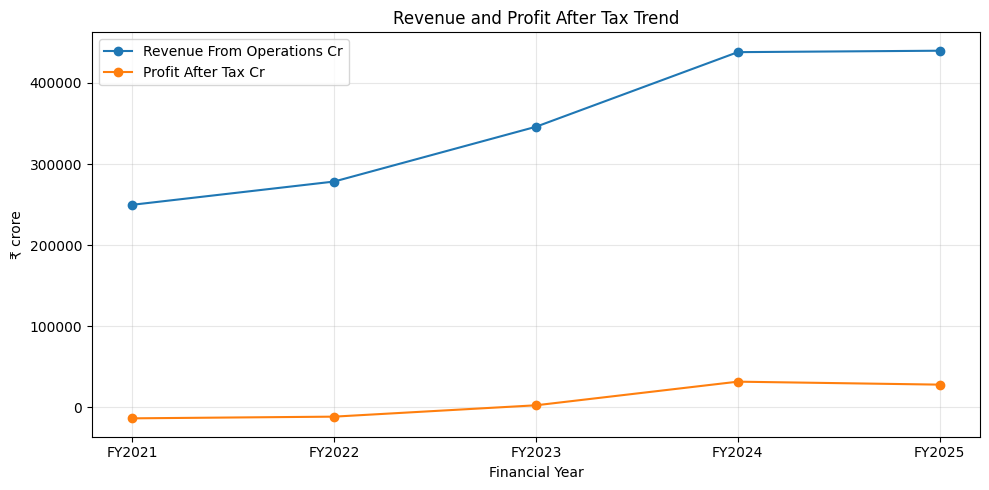

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\revenue_pat_trend.png


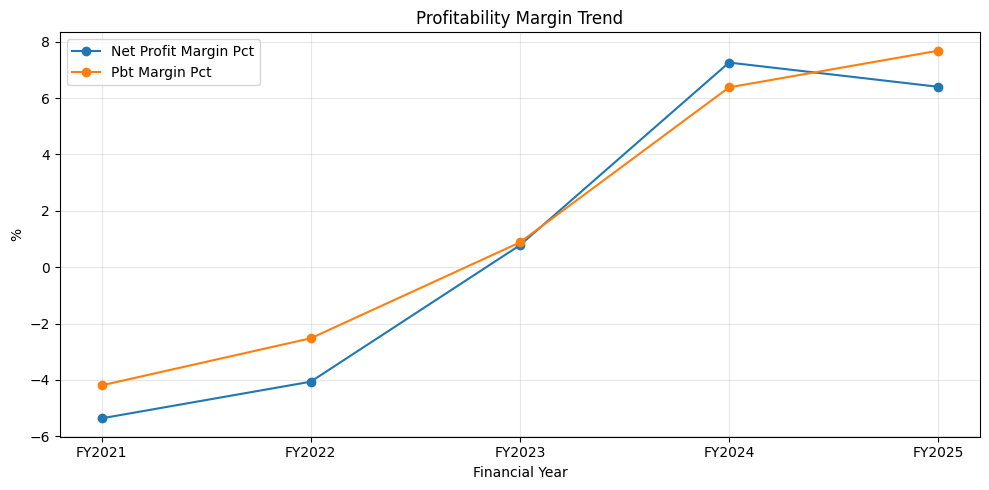

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\profitability_margin_trend.png


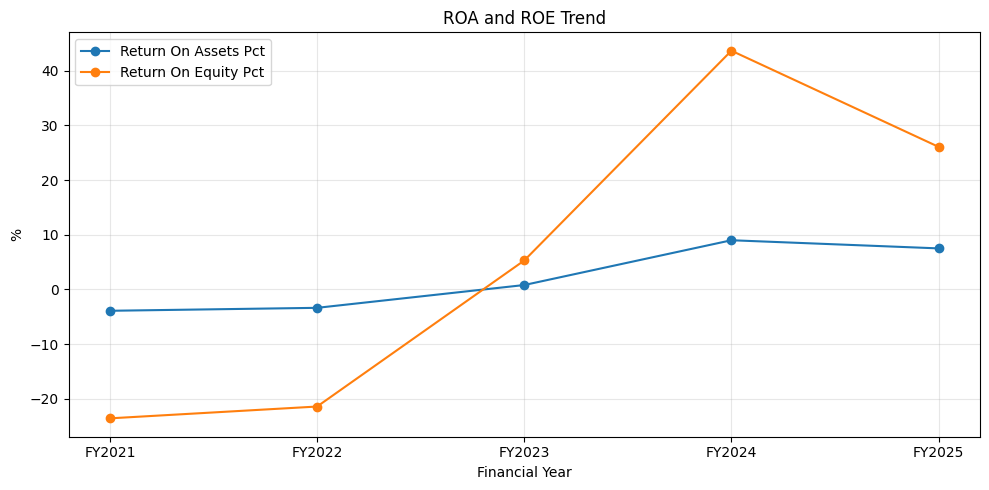

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\roa_roe_trend.png


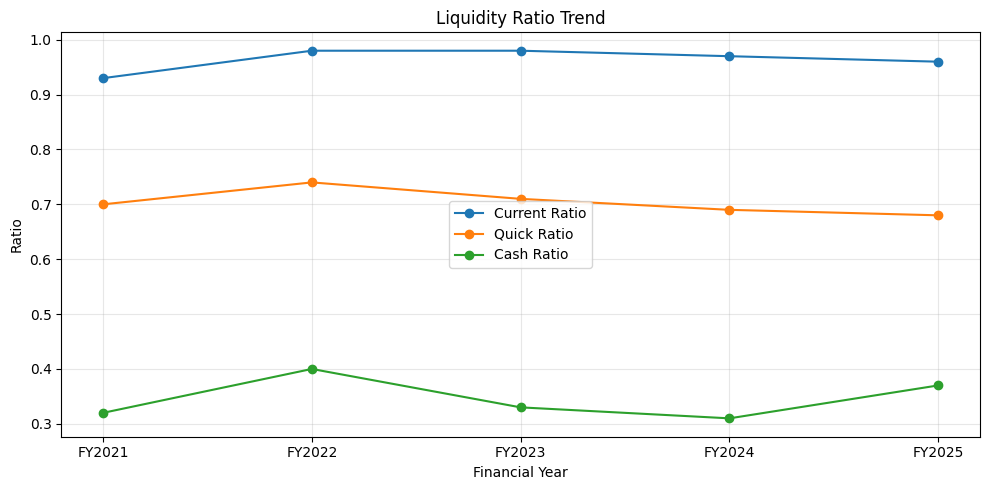

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\liquidity_ratio_trend.png


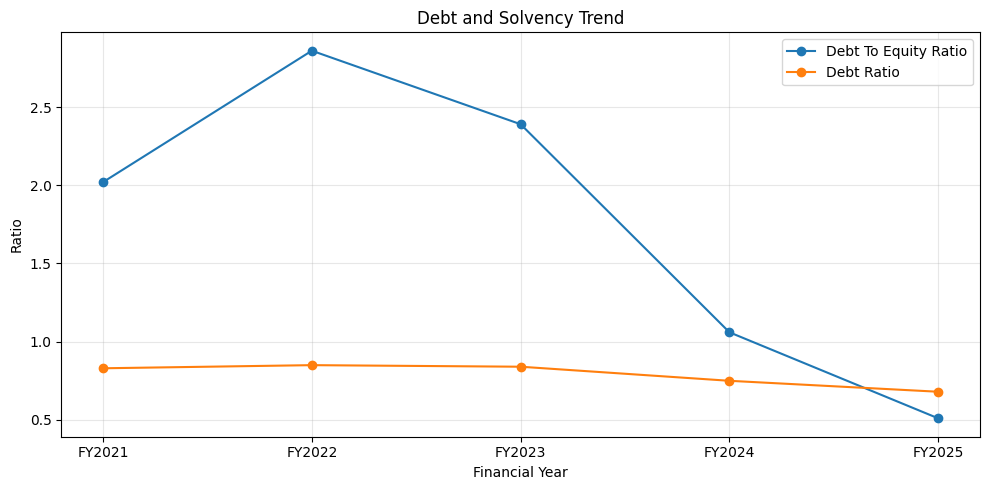

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\debt_solvency_trend.png


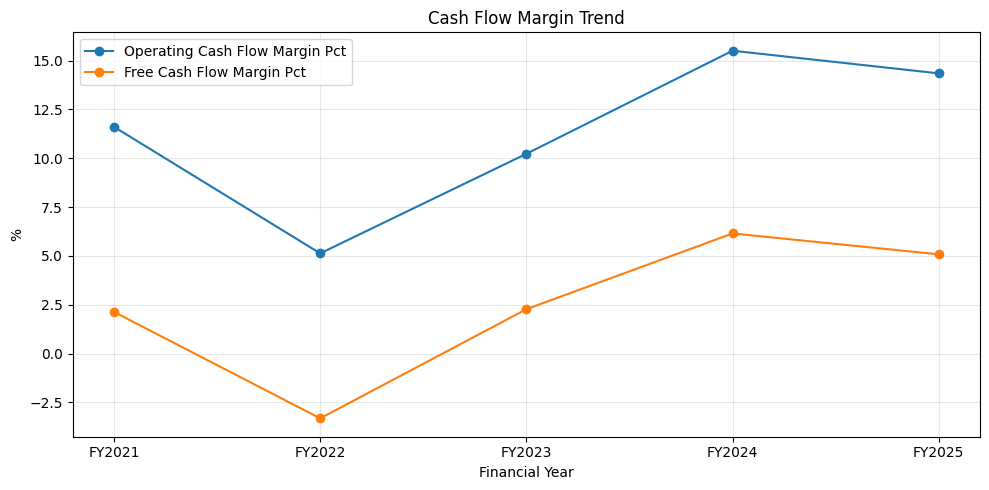

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\cash_flow_margin_trend.png


In [9]:
def save_line_chart(df, x_col, y_cols, title, y_label, file_name):
    """I create and save a simple line chart for one or more financial metrics."""
    plt.figure(figsize=(10, 5))
    for col in y_cols:
        plt.plot(df[x_col], df[col], marker="o", label=col.replace("_", " ").title())
    plt.title(title)
    plt.xlabel("Financial Year")
    plt.ylabel(y_label)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    output_path = CHARTS_DIR / file_name
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

save_line_chart(
    analysis,
    "financial_year",
    ["revenue_from_operations_cr", "profit_after_tax_cr"],
    "Revenue and Profit After Tax Trend",
    "₹ crore",
    "revenue_pat_trend.png",
)

save_line_chart(
    analysis,
    "financial_year",
    ["net_profit_margin_pct", "pbt_margin_pct"],
    "Profitability Margin Trend",
    "%",
    "profitability_margin_trend.png",
)

save_line_chart(
    analysis,
    "financial_year",
    ["return_on_assets_pct", "return_on_equity_pct"],
    "ROA and ROE Trend",
    "%",
    "roa_roe_trend.png",
)

save_line_chart(
    analysis,
    "financial_year",
    ["current_ratio", "quick_ratio", "cash_ratio"],
    "Liquidity Ratio Trend",
    "Ratio",
    "liquidity_ratio_trend.png",
)

save_line_chart(
    analysis,
    "financial_year",
    ["debt_to_equity_ratio", "debt_ratio"],
    "Debt and Solvency Trend",
    "Ratio",
    "debt_solvency_trend.png",
)

save_line_chart(
    analysis,
    "financial_year",
    ["operating_cash_flow_margin_pct", "free_cash_flow_margin_pct"],
    "Cash Flow Margin Trend",
    "%",
    "cash_flow_margin_trend.png",
)

## 10. Create a business health scorecard

In this step, I create a simple scorecard to summarize the financial health trend in a way that is easy to explain during interviews.

In [10]:
def score_profitability(row):
    if row["net_profit_margin_pct"] >= 5:
        return 2
    if row["net_profit_margin_pct"] >= 0:
        return 1
    return 0

def score_liquidity(row):
    if row["current_ratio"] >= 1.2:
        return 2
    if row["current_ratio"] >= 0.8:
        return 1
    return 0

def score_solvency(row):
    if row["debt_to_equity_ratio"] <= 1:
        return 2
    if row["debt_to_equity_ratio"] <= 2:
        return 1
    return 0

def score_cash_flow(row):
    if row["free_cash_flow_margin_pct"] >= 5:
        return 2
    if row["free_cash_flow_margin_pct"] >= 0:
        return 1
    return 0

scorecard = analysis[["financial_year"]].copy()
scorecard["profitability_score"] = analysis.apply(score_profitability, axis=1)
scorecard["liquidity_score"] = analysis.apply(score_liquidity, axis=1)
scorecard["solvency_score"] = analysis.apply(score_solvency, axis=1)
scorecard["cash_flow_score"] = analysis.apply(score_cash_flow, axis=1)
scorecard["overall_score"] = scorecard[["profitability_score", "liquidity_score", "solvency_score", "cash_flow_score"]].sum(axis=1)
scorecard["overall_score_pct"] = (scorecard["overall_score"] / 8) * 100

scorecard.to_csv(REPORTS_DIR / "business_health_scorecard_detailed.csv", index=False)

display(scorecard)
print("Saved:", REPORTS_DIR / "business_health_scorecard_detailed.csv")

,financial_year,profitability_score,liquidity_score,solvency_score,cash_flow_score,overall_score,overall_score_pct
0,FY2021,0,1,0,1,2,25.0
1,FY2022,0,1,0,0,1,12.5
2,FY2023,1,1,0,1,3,37.5
3,FY2024,2,1,1,2,6,75.0
4,FY2025,2,1,2,2,7,87.5


Saved: D:\Github Project\Tata Motors Financial Analysis\reports\business_health_scorecard_detailed.csv


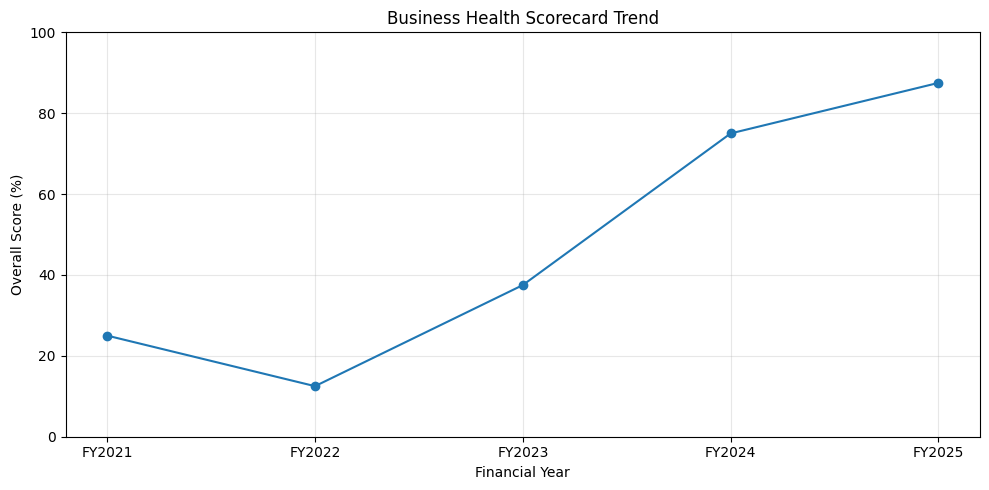

Saved: D:\Github Project\Tata Motors Financial Analysis\reports\charts\business_health_scorecard_trend.png


In [11]:
plt.figure(figsize=(10, 5))
plt.plot(scorecard["financial_year"], scorecard["overall_score_pct"], marker="o")
plt.title("Business Health Scorecard Trend")
plt.xlabel("Financial Year")
plt.ylabel("Overall Score (%)")
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.tight_layout()
output_path = CHARTS_DIR / "business_health_scorecard_trend.png"
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", output_path)

## 11. Final validation of outputs

In this step, I check that the notebook created the key report files and chart images successfully.

In [13]:
expected_report_files = [
    REPORTS_DIR / "executive_financial_summary.csv",
    REPORTS_DIR / "key_business_insights.csv",
    REPORTS_DIR / "management_recommendations.csv",
    REPORTS_DIR / "business_health_scorecard_detailed.csv",
]

expected_chart_files = [
    CHARTS_DIR / "revenue_pat_trend.png",
    CHARTS_DIR / "profitability_margin_trend.png",
    CHARTS_DIR / "roa_roe_trend.png",
    CHARTS_DIR / "liquidity_ratio_trend.png",
    CHARTS_DIR / "debt_solvency_trend.png",
    CHARTS_DIR / "cash_flow_margin_trend.png",
    CHARTS_DIR / "business_health_scorecard_trend.png",
]

missing_outputs = [path for path in expected_report_files + expected_chart_files if not path.exists()]

if missing_outputs:
    raise FileNotFoundError(f"Some expected outputs were not created: {missing_outputs}")

print("All expected insight tables and charts were created successfully.")
print("Report files created:")
for path in expected_report_files:
    print("-", path.relative_to(PROJECT_ROOT))

print("Chart files created:")
for path in expected_chart_files:
    print("-", path.relative_to(PROJECT_ROOT))

All expected insight tables and charts were created successfully.
Report files created:
- reports\executive_financial_summary.csv
- reports\key_business_insights.csv
- reports\management_recommendations.csv
- reports\business_health_scorecard_detailed.csv
Chart files created:
- reports\charts\revenue_pat_trend.png
- reports\charts\profitability_margin_trend.png
- reports\charts\roa_roe_trend.png
- reports\charts\liquidity_ratio_trend.png
- reports\charts\debt_solvency_trend.png
- reports\charts\cash_flow_margin_trend.png
- reports\charts\business_health_scorecard_trend.png


## 12. Notebook conclusion

At this stage, I have created the main business insights, recommendations, and visual outputs needed for the next project stages.

The next step after this notebook is to create the SQL files for database table creation and analysis queries. Those SQL files will help me show that I can analyze financial data using SQL in addition to Python.